# TME 7 - Simulation financière des micro-fermes

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
import tme7

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


La semaine dernière s'est terminée avec un code permettant de simuler un grand nombre de micro-fermes valides. Cette simulation étant un peu lente, vous avez dans le répertoire `res` un fichier json contenant 10 000 microfermes valides (à peu près 950 minutes pour sa génération).

In [3]:
import json
with open("redf.iloc[l]['ID']s/fermes.json","r") as file_of_fermes:
  fermes=json.load(file_of_fermes)
print(f"nombre de fermes : {len(fermes)}")

# nous allons souvent utilisé la première ferme
print("\nPremière micro-ferme (f0):\n")
f0=fermes[0]
print(f0)

nombre de fermes : 10000

Première micro-ferme (f0):

{'514': 32.0, '352': 8.0, '485': 24.0, '490': 8.0, '295': 38.0, '576': 20.0, '336': 24.0, '387': 35.0, '463': 16.0, '491': 40.0, '442': 4.0, '498': 16.0, '541': 28.0, '390': 32.0, '460': 12.0, '315': 8.0, '414': 12.0, '330': 16.0, '328': 8.0, '313': 8.0, '396': 12.0, '440': 8.0, '523': 8.0, '304': 8.0, '397': 20.0, '395': 16.0, '325': 8.0, '356': 20.0, '504': 8.0, '366': 12.0, '518': 12.0, '503': 16.0, '342': 32.0, '470': 8.0, '383': 16.0, '519': 12.0, '378': 8.0, '466': 12.0, '364': 4.0, '528': 4.0}


## Q0.1 : dictionnaire ID->nom

Les micro-fermes sont définis par des productions de parcelles dont on connait l'ID (comme '514'). Nous aurons besoin des noms de légume plutôt que des ID des parcelles. Cette correspondance se trouve dans le fichier `res/cropping_cycles.csv` (plusieur IDs peuvent correspondre au même légume).

Écrire une fonction qui génère un dictionnaire `ID2Name` à partir d'un fichier `res/cropping_cycles.csv` 

In [14]:
df = pd.read_csv("res/cropping_cycles.csv")

In [18]:
df.iloc[514]["Crop_french"]

'Radis conservation'

In [20]:
IDdico2Name=tme7.genereID2Name("res/cropping_cycles.csv")
df.iloc[l]['ID']
#utilisation
print("ID  |        légume                  | nb de lots")
print("----|--------------------------------|-----------")
for k in f0:
  print(f"{k:3} | {IDdico2Name[k]:30} | {f0[k]}")

ID  |        légume                  | nb de lots
----|--------------------------------|-----------
514 | Pomme de terre conservation    | 32.0
352 | Chou                           | 8.0
485 | Navet conservation             | 24.0
490 | Oignon botte                   | 8.0
295 | Ail conservation               | 38.0
576 | Tomate classique               | 20.0
336 | Carotte conservation           | 24.0
387 | Courge                         | 35.0
463 | Mesclun                        | 16.0
491 | Oignon conservation            | 40.0
442 | Mache-pourp                    | 4.0
498 | Poireau                        | 16.0
541 | Radis conservation             | 28.0
390 | Courge                         | 32.0
460 | Mesclun                        | 12.0
315 | Betterave botte                | 8.0
414 | Epinard                        | 12.0
330 | Carotte botte                  | 16.0
328 | Carotte botte                  | 8.0
313 | Betterave botte                | 8.0
396 | Courgette           

## 1- Simulations pour un légume

Bien entendu, connaître les caractéristiques d'une micro-ferme sont nécessaires mais pas suffisant pour estimer son rendement. Il faut prendre en compte un certain nombre d'aléas qui peuvent se produire lors de l'année.

### Modélisation du rendement d'un légume cultivé pour la micro-ferme

Pour un légume $c$, on suppose que son rendement $Y_c$ (rendement par $m^2$) est composé de plusieurs processus aléatoires et vérifie l'équation suivante : 

$$log(Y_c) = A_s + A_f + a_c + V$$

où les différentes composantes modélisent différents aléas  :

- le légume $c$ a son propre rendement : $a_c$
- La ferme elle-même ($f$) crée un aléas $A_f \sim {\cal N}(\mu_{A_f}=0,\sigma_{A_f}=0.42)$
- Le système de fonctionnement ($s$) donne une composante aléatoire $A_s \sim {\cal N}(\mu_{A_s}=0.74,\sigma_{A_s}=0.12)$
- Enfin, il y a un aléas pur (un risque) : $V \sim {\cal N}(\mu_V=0,\sigma_V=0.14)$


### Modélisation de la charge de travail pour un légume cultivé dans la micro-ferme

La charge de travail nécessaire à la production du légume $c$ (en heure par $m^2$) est également composé de plusieurs processus aléatoires :

$$log(W_c) = B_s + B_f + b_c + W$$

où les différentes composantes modélisent différents aléas  :

- le légume $c$ a sa charged de travail propre : $b_c$
- La ferme elle-même ($f$) crée un aléas $B_f \sim {\cal N}(\mu_{B_f}=0,\sigma_{B_f}=0.36)$
- Le système de fonctionnement ($s$) donne une composante aléatoire $B_s \sim {\cal N}(\mu_{B_s}=2.72,\sigma_{B_s}=0.19)$
- Enfin, il y a un aléas pur (un risque) : $W \sim {\cal N}(\mu_W=0,\sigma_W=0.21)$

Un dictionnaire `cost_model` contient tous ces paramètres :

In [21]:
cost_model={
  "muAf":0,
  "sigmaAf":0.42,
  "muAs":0.74,
  "sigmaAs":0.12,
  "muV":0,
  "sigmaV":0.14,
  
  "muBf":0,
  "sigmaBf":0.36,
  "muBs":2.72,
  "sigmaBs":0.19,
  "muW":0,
  "sigmaW":0.21,
}

### Caractérisiques des légumes
On dispose d'une base de données `res/crop_properties.csv` qui donne pour chaque légume:
* son prix au kilo 
* la quantité par parcelle en kg
* les paramètres $a_c$ et $b_c$ qui décrivent le rendement et la charge de travail associé au légume $c$.

In [22]:
props=pd.read_csv("res/crop_properties.csv")
props.head()

,Crop_french,Price,Quantity_per_share,bc,ac
0,Aubergine,3.90,0.70,0.38,0.63
1,Betterave botte,3.04,0.80,-0.26,0.18
2,Betterave conservation,2.58,0.63,-0.06,0.67
3,Feve,4.08,1.00,-0.16,-0.06
4,Brocoli,3.57,0.50,-0.51,-1.04


Il s'agit maintenant de mener des simulations aléatoires, nous allons donc régulièrement forcer la "graine" du générateur pseudo-aléatoire afin d'avoir des résultats déterministes. Toutefois vos résultats ne seront pas forcément les mêmes que ceux présentés dans l'énoncé puique des codes différents peuvent impliquer des appels à ce générateur dans des ordres différents.

### Q1.1 : Simulation du rendement d'un légume : $Y_c$

On note $Z_c=log(Y_c)$.

Proposer une fonction `simulate_profit_legume(c,props,cost_model)` qui simule un rendement pour un légume `c` à partir ses arguments et qui rend le couple de valeurs tirés pour $(Z_c,Y_c)$. 


In [31]:
np.random.seed(42)
tme7.simulate_profit_legume("Aubergine",props,cost_model)

(1.4622110872035474, 4.315490913836398)

On peut utiliser cette fonction pour simuler la distribution de $Y_c$ et $Z_c$ pour un légume particulier. 

Proposer une fonction qui génère `N` échantillons de $Y_c$ et $Z_c$ , qui dessine les histogrammes (en utilsant le nombre de bins `bins`) et qui rend la moyenne et l'écart-type des 2 distributions.

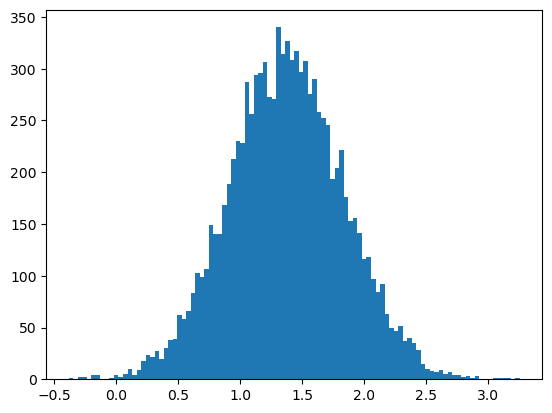

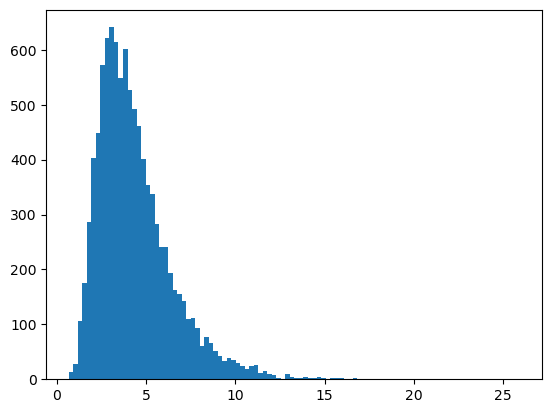

(1.3742924850838003, 0.4608538629040844, 4.397139692779112, 2.160195594188869)

In [39]:
tme7.distribution_rendement_legume("Aubergine",props,cost_model,
                                  N=10000,bins=100)

Pouvait-on prévoir ces résultats ? Proposer une fonction `parametres_rendement_legume("Aubergine",props,cost_model)` qui donne les valeurs théoriques de ces moyennes et écart-types ?

*(n'hésitez pas à aller voir https://fr.wikipedia.org/wiki/Loi_log-normale)*

In [47]:
tme7.parametres_rendement_legume("Aubergine",props,cost_model)

(1.37, 0.4586937976471886, 4.371910067510888, 2.115623386146689)

### Q1.2 : Simulation de la charge de travail pour un légume : $W_c$

On note $T_c=log(W_c)$. On peut alors faire le même travail pour la charge que, plus haut, pour le rendement :

Proposer une fonction `simulate_charge_legume(c,props,cost_model)` qui simule une charge de travail pour un légume `c` à partir ses arguments et qui rend le couple de valeurs tirés pour $(T_c,W_c)$. 

In [48]:
np.random.seed(42)
tme7.simulate_charge_legume("Aubergine",props,cost_model)

(3.2806151336516534, 26.592125381006934)

## 2- Simulation d'une microferme

Les modélisations précédentes concernaient un légume et étaient données par $m^2$ de production. Pour pouvoir simuler le rendement et la charge d'une ferme dans son ensemble, il faut, pour chaque parcelle, obtenir la surface nécessaire pour cette production.

Pour une ferme `f`, pour une parcelle d'id `i`, la description de la ferme donne la production qui est attendue en nombre de lot (share) : `f[i]`. Il suffit alors de trouver `c` le légume associé, de récupérer la `q_c`="quantity_per_share' dans `props`, de simuler `Y_c` le rendement obtenu par $m^2$ de cette parcelle, la surface sera alors `f[i]*q_c/Y_c`. Il est à noter qu'on suppose que la ferme n'a pas de limite en surface cultivable, ce qui est une limite de notre simulation.

Par ailleurs, pour un légume `c`, `props` fournit également le prix de vente `p_c`="Price", ce qui permet alors de calculer le chiffre d'affaire issus de cette parcelle : `f[i]*q_c*p_c`

### Q2.1 : Simulation du chiffre d'affaire, du rendement et de la charge de travail associé à un couple (id,nbLot)

Proposer une fonction `simule_parcelle(id,qte,id2name,props,cost_model)` qui fournit une simulation du triplet `(surface,Y_c,W_c,p_c)` d'une parcelle. 


In [10]:
np.random.seed(42)
s,y,w,p=tme7.simulate_parcelle("514",32,ID2Name,props,cost_model)

print(f"surface         : s={s:5.2f} m2")
print(f"rendement au m2 : y={y:5.2f}       (production de la parcelle : {s*y=}=32)")
print(f"charge au m2    : w={w:5.2f}       (charge de la parcelle     : {s*w=}")
print(f"CA              : p={p:5.2f}")

surface         : s=11.40 m2
rendement au m2 : y= 2.81       (production de la parcelle : s*y=32.0=32)
charge au m2    : w=20.20       (charge de la parcelle     : s*w=230.3123687381079
CA              : p=67.20


### Q2.2 : Simulation du chiffre d'affaire et de la charge de travail associé à une ferme

En itérant maintenant sur l'ensemble des parcelles de la ferme, nous pouvons donc maintenant obtenir une production et une charge de travail pour la ferme.

Proposer la fonction `simulate_ferme(ferme,id2name,props,cost_model)` qui fournit une simulation du triplet `(surface,CA_total,charge_totale)` d'une ferme. 

In [11]:
np.random.seed(42)
tme7.simulate_ferme(f0,ID2Name,props,cost_model)

(248.04104142213072, 1567.2837000000004, 4389.783803298017)

### Q2.3 : Distributions associées à une ferme

De même que plus haut, on peut donc représenter les distributions des 3 grandeurs obtenues `surface,CA_total,charge_totale`. Que pensez vous du résultat ? 

{'E(Surface)': 220.3740814305513,
 's(Surface)': 19.958095368632698,
 'E(CA_total)': 1567.2837000000002,
 's(CA_total)': 2.2737367544323206e-13,
 'E(Charge_total)': 3711.271725701017,
 's(Charge_total)': 490.8474136246962}

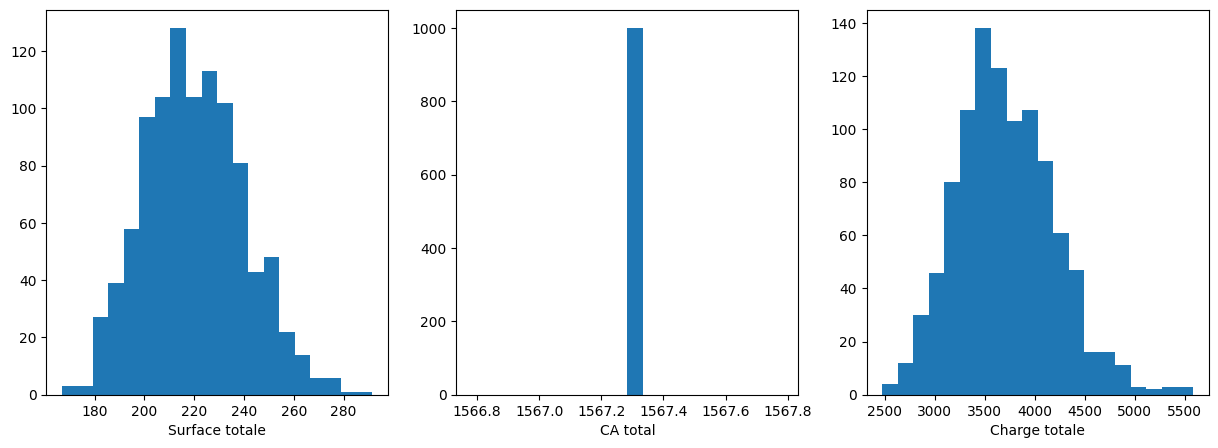

In [12]:
tme7.distribution_ferme(f0,ID2Name,props,cost_model,
                        N=1000,bins=20)

## 3- Estimation de la viabilité économique d'une micro-ferme.

La viabilité économique d'une micro-ferme se détermine dans un espace multi-critère : CA,charge de travail totale

### Q3.1: Génération de points dans l'espace des critères

Proposer une function `get_simulated_points(fermes_list,id2name,props,cost_model))` qui simule des points `(CA,charge)` pour toutes les fermes de la liste.


In [13]:
np.random.seed(42)
points=tme7.get_simulated_points(fermes[:10],ID2Name,props,cost_model)
points

[(1567.2837000000004, 4389.783803298017),
 (1663.6574000000003, 3365.9373436235956),
 (1654.2459999999999, 3967.9769606642794),
 (1728.1548000000003, 3629.818792767065),
 (1722.358, 4138.159305761968),
 (1786.2072, 4252.703078106847),
 (1676.8732, 2971.635658837617),
 (1791.8106000000002, 4507.500045507446),
 (1575.0478000000003, 3995.314907957186),
 (1726.5132000000006, 3998.6172924114917)]

In [14]:
CA_min=1000
Charge_max=500

In [15]:
# attention le calcul sur les 10 000 fermes est un peu long (2 minutes 30)
#points=tme7.get_simulated_points(fermes,ID2Name,props,cost_model)

with open("res/points1.json","r") as f:
  points1=json.load(f)
with open("res/points2.json","r") as f:
  points2=json.load(f)
with open("res/points3.json","r") as f:
  points3=json.load(f)

# vous pourrez tester avec les 3 bases si vous voulez. Nous prenons ici la base 1
#points=points1+points2+points3
points=points1

### Q3.2: Viabilité des fermes dans l'espace des critères 

Plus exactement, on considérera qu'une ferme est viable financièrement par rapport à un minimum de CA et par rapport à un maximum de charge de travail total. On propose de définir (arbitrairement) des valeurs à ces limites.
Proposer une fonction `show_points(points,CA_min,charge_max)` que trace une représentation des points précédents en utilisant un `plt.scatter` et en visualisation la zone de non viabilité.

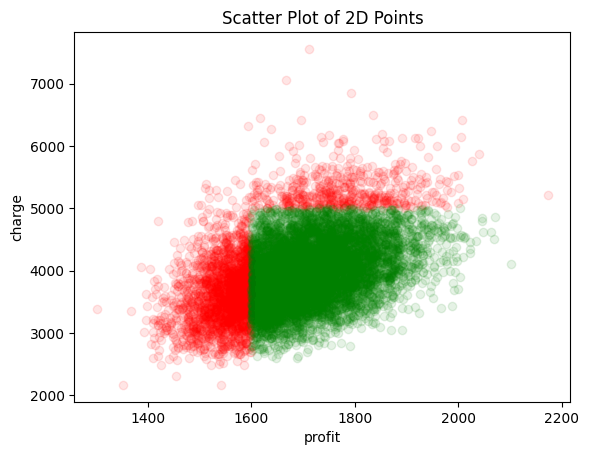

In [16]:
tme7.show_points(points,1600,5000)

### Q3.3: probabilité de viabilité

On note $V$ la variable *viability* qui est une variable de Bernouilli indiquant si une ferme est viable ou non. Donc $V \sim {\cal B}(p)$ où $p$ est la probabilité d'être viable.

Proposer une fonction `get_viability(points,ca_min,charge_max)` permettant d'estimer le couple (espérance,variance) de $V$ en utilisant `points`.

In [17]:
tme7.get_viability(points,1600,5000)

(0.737, 0.193831)

Proposer une fonction `show_viability(D,points,ca_min,charge_max)` qui affiche une suite d'estimation en utilisant les `K` premiers points de la base pour `K` variant de $D$ à $10000$ par pas de $D$. Afficher également les intervalles de confiance (au niveau de confiance 95%) en supposant que la variance calculée sur l'échantillon est la bonne estimation de la variance totale.

Remarquer l'impact de la granularité de la courbe sur son aspect général.

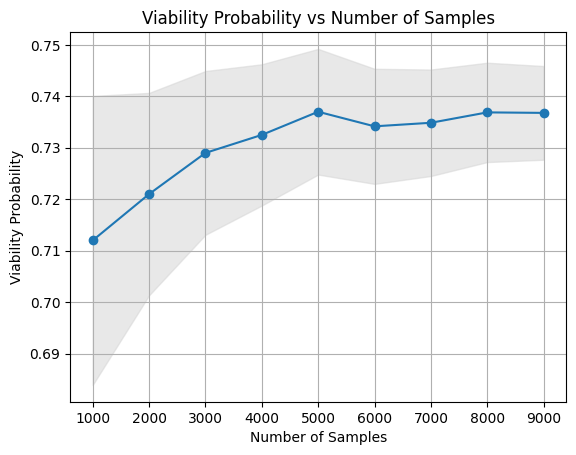

In [18]:
tme7.show_viability(1000,points,1600,5000) # quand il y a moins de 20 points à afficher, nous les signalons par un marker="o"

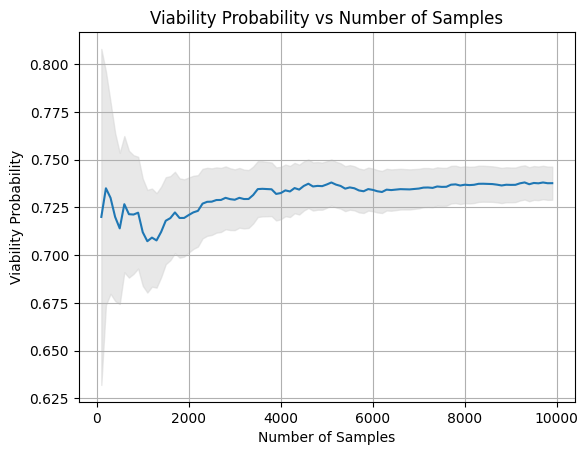

In [19]:
tme7.show_viability(100,points,1600,5000)

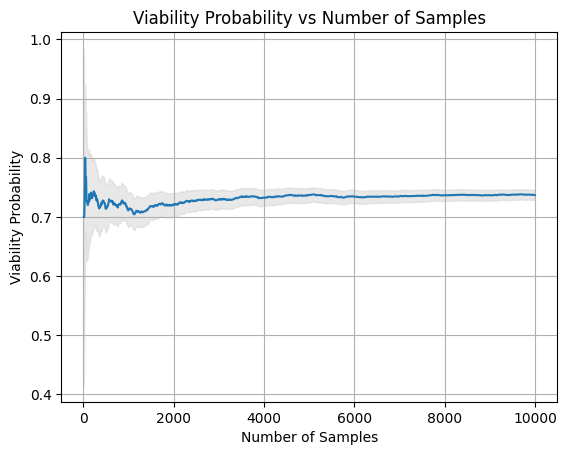

In [20]:
tme7.show_viability(10,points,1600,5000)